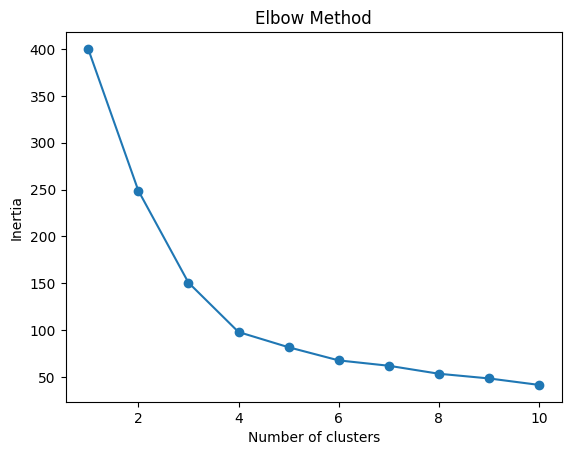

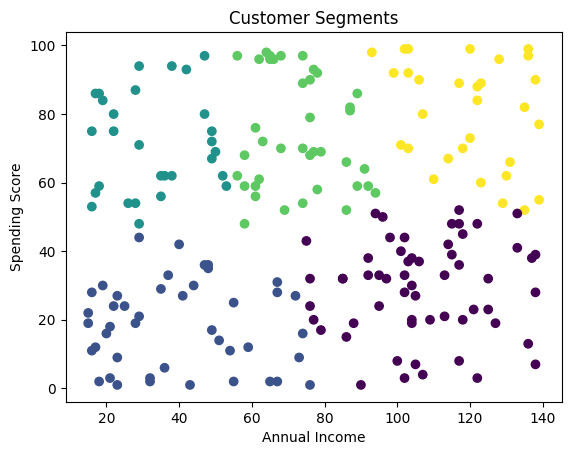

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Create dummy data (Mall Customers: Spending Score vs Annual Income)
np.random.seed(42)
data = {
    'Annual_Income': np.random.randint(15, 140, 200),
    'Spending_Score': np.random.randint(1, 100, 200)
}
df = pd.DataFrame(data)

# 2. Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# 3. Elbow Method to find 'k'
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

# 4. Fit K-Means (Let's assume k=5 based on the plot)
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(scaled_data)

# 5. Visualize with PCA (or just the 2 features since we only have 2)
plt.scatter(df['Annual_Income'], df['Spending_Score'], c=clusters, cmap='viridis')
plt.title('Customer Segments')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()